# Bootcamp Sesión 5 
### Estrategia Buy Bitcoin Baby

Octubre 2024

In [1]:
import os
from dotenv import load_dotenv
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
load_dotenv()


API_KEY = os.environ['FMP']

def get_full_price_data(ticker,  API_KEY):
    # Crear la URL dinámica con los parámetros de entrada
    url = f'https://financialmodelingprep.com/api/v3/historical-price-full/{ticker}?apikey={API_KEY}'
    
    # Hacer la solicitud GET a la API
    response = requests.get(url)
    
    # Comprobar si la respuesta fue exitosa (status code 200)
    if response.status_code == 200:
        # Convertir la respuesta a formato JSON
        data = response.json()
        df = pd.DataFrame(data['historical'])
        df = df.assign(ticker = f'{ticker}')
        return df
    else:
        # Si hubo un error, devolver el código de error
        print(f"Error: {response.status_code}")
        return None

        
# Calcular Métricas (Bandas de Bollinger)
def get_b_bands(data, n):
    """
    Calcular bandas de bollinger

    Parametros
    ----------
    data : pd.Series
        Precio de Cierre.
    n : int
        Número de velas.

    Regresa
    -------
    df : pd.DataFrame
        Bandas de Bollinger + Precio de Cierre df.

    """
    MA = pd.Series(pd.Series.rolling(data, n).mean())  
    MSD = pd.Series(pd.Series.rolling(data, n).std())  
    b1 = MA + (MSD*2) 
    B1 = pd.Series(b1, name = 'BB_' + str(n))  
    df = pd.concat([data,B1], axis=1)  
    b2 = MA - (MSD*2)  
    B2 = pd.Series(b2, name = 'Bb_' + str(n))  
    df = pd.concat([df,B2], axis=1)  
    df.reset_index(inplace=True,drop=True)
    return df


# Crear señales
def apply_mean_reverse(data, n):
    """
    Crear estrategia de regresion a la media con base en bandas de bollinger

    Parametros
    ----------
    data : pd.DataFrame
        Datos provenientes del exchange.
        
    n     : int
        Ventana de tiempo de las Bandas Bollinger.

    Regresa
    -------
    signal : bool
        Señal de la estrategia para comprar, vender o pasar.
    
    data  : pd.DataFrame
        Datos finales de la estrategia
    """
    
    # Calcular Bandas de Bollinger
    bbands = get_b_bands(data['close'], n)
    
    # Crear columnas Side (1, -1) y Side Ref (Ref Precio)
    bbands['side'] = np.nan 
    bbands['side_ref'] = np.nan
    
    # Crear mascara booleana de posiciones
    long_signals = (bbands['close'] <= bbands[f'Bb_{n}']) 
    short_signals = (bbands['close'] >= bbands[f'BB_{n}']) 
    
    # Asignar valores de Side y Sider Ref
    bbands.loc[long_signals, 'side_ref'] = bbands['close']
    bbands.loc[short_signals, 'side_ref'] = bbands['close']
    
    bbands.loc[long_signals, 'side'] = 1
    bbands.loc[short_signals, 'side'] = -1
    
    # Aplicar lógica para definir output
    if bbands['side'].iloc[-1] == 1:
        return True, bbands
    
    if bbands['side'].iloc[-1] == -1:
        return False, bbands
    else:
        return None, bbands
    

In [2]:
data = get_full_price_data('TSLA', API_KEY)

In [3]:
data['date'] = pd.to_datetime(data['date'])
data_s = data.set_index('date')['close'][::-1]

data_s_backtest = data.set_index('date')[::-1]

In [4]:
bbands = get_b_bands(data_s, 20)

In [5]:
bbands

,close,BB_20,Bb_20
0,17.04,NaN,NaN
1,16.98,NaN,NaN
2,19.98,NaN,NaN
3,21.88,NaN,NaN
4,21.85,NaN,NaN
...,...,...,...
1253,219.57,270.543084,216.099916
1254,221.33,271.094912,214.961088
1255,220.89,271.628444,212.124556
1256,220.70,272.201189,209.796811


<Axes: >

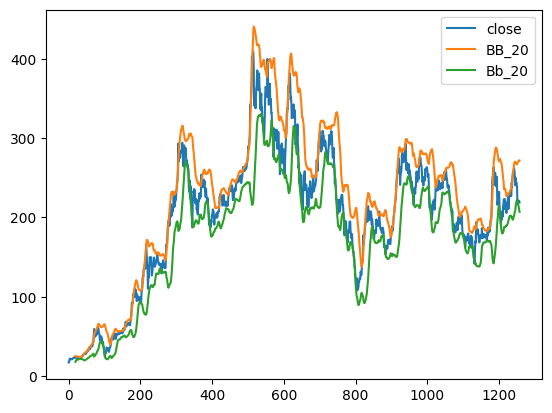

In [6]:
bbands.plot(kind='line')

In [7]:
app = apply_mean_reverse(bbands, 20)

In [8]:
app

(None,
        close       BB_20       Bb_20  side  side_ref
 0      17.04         NaN         NaN   NaN       NaN
 1      16.98         NaN         NaN   NaN       NaN
 2      19.98         NaN         NaN   NaN       NaN
 3      21.88         NaN         NaN   NaN       NaN
 4      21.85         NaN         NaN   NaN       NaN
 ...      ...         ...         ...   ...       ...
 1253  219.57  270.543084  216.099916   NaN       NaN
 1254  221.33  271.094912  214.961088   NaN       NaN
 1255  220.89  271.628444  212.124556   NaN       NaN
 1256  220.70  272.201189  209.796811   NaN       NaN
 1257  218.85  271.838813  207.044187   NaN       NaN
 
 [1258 rows x 5 columns])

In [9]:
app[0]

<Axes: >

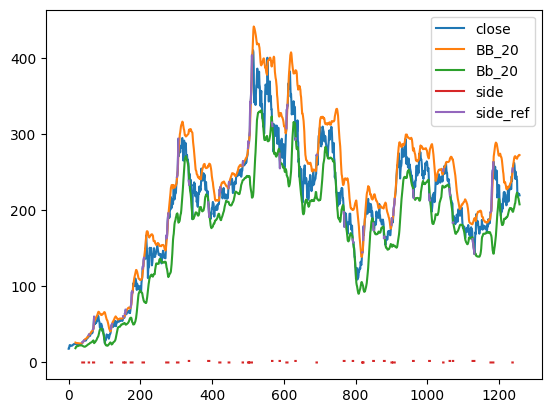

In [10]:
app[1].plot()

In [11]:
from backtesting import Backtest, Strategy
from backtesting.lib import crossover, cross


/opt/conda/envs/pypro/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/pypro/lib/python3.10/site-packages/backtesting/_plotting.py:50: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support (e.g. PyCharm, Spyder IDE). Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [12]:

from backtesting.test import SMA, GOOG


/opt/conda/envs/pypro/lib/python3.10/site-packages/backtesting/test/__init__.py:8: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.read_csv(join(dirname(__file__), filename),
/opt/conda/envs/pypro/lib/python3.10/site-packages/backtesting/test/__init__.py:8: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.read_csv(join(dirname(__file__), filename),


In [13]:
help(SMA)

Help on function SMA in module backtesting.test:

SMA(arr: pandas.core.series.Series, n: int) -> pandas.core.series.Series
    Returns `n`-period simple moving average of array `arr`.



In [14]:
SMA([100,100,100], 2)

0      NaN
1    100.0
2    100.0
dtype: float64

In [15]:
help(Backtest)

Help on class Backtest in module backtesting.backtesting:

class Backtest(builtins.object)
 |  Backtest(data: pandas.core.frame.DataFrame, strategy: Type[backtesting.backtesting.Strategy], *, cash: float = 10000, commission: float = 0.0, margin: float = 1.0, trade_on_close=False, hedging=False, exclusive_orders=False)
 |  
 |  Backtest a particular (parameterized) strategy
 |  on particular data.
 |  
 |  Upon initialization, call method
 |  `backtesting.backtesting.Backtest.run` to run a backtest
 |  instance, or `backtesting.backtesting.Backtest.optimize` to
 |  optimize it.
 |  
 |  Methods defined here:
 |  
 |  __init__(self, data: pandas.core.frame.DataFrame, strategy: Type[backtesting.backtesting.Strategy], *, cash: float = 10000, commission: float = 0.0, margin: float = 1.0, trade_on_close=False, hedging=False, exclusive_orders=False)
 |      Initialize a backtest. Requires data and a strategy to test.
 |      
 |      `data` is a `pd.DataFrame` with columns:
 |      `Open`, `H

In [16]:
help(Strategy)

Help on class Strategy in module backtesting.backtesting:

class Strategy(builtins.object)
 |  Strategy(broker, data, params)
 |  
 |  A trading strategy base class. Extend this class and
 |  override methods
 |  `backtesting.backtesting.Strategy.init` and
 |  `backtesting.backtesting.Strategy.next` to define
 |  your own strategy.
 |  
 |  Methods defined here:
 |  
 |  I(self, func: Callable, *args, name=None, plot=True, overlay=None, color=None, scatter=False, **kwargs) -> numpy.ndarray
 |      Declare indicator. An indicator is just an array of values,
 |      but one that is revealed gradually in
 |      `backtesting.backtesting.Strategy.next` much like
 |      `backtesting.backtesting.Strategy.data` is.
 |      Returns `np.ndarray` of indicator values.
 |      
 |      `func` is a function that returns the indicator array(s) of
 |      same length as `backtesting.backtesting.Strategy.data`.
 |      
 |      In the plot legend, the indicator is labeled with
 |      function name, 

In [17]:
help(Strategy.buy)

Help on function buy in module backtesting.backtesting:

buy(self, *, size: float = .9999, limit: float = None, stop: float = None, sl: float = None, tp: float = None)
    Place a new long order. For explanation of parameters, see `Order` and its properties.
    
    See also `Strategy.sell()`.



In [18]:


class SmaCross(Strategy):
    def init(self):
        price = self.data.Close
        self.ma1 = self.I(SMA, price, 10)
        self.ma2 = self.I(SMA, price, 200)

    def next(self):
        if crossover(self.ma1, self.ma2):
            self.buy()
        elif crossover(self.ma2, self.ma1):
            self.sell()

"""
SMA(arr: pandas.core.series.Series, n: int) -> pandas.core.series.Series
    Returns `n`-period simple moving average of array `arr`.
"""
# Función para calcular la banda baja de Bollinger
def bollinger_lower_band(arr_: pd.Series, n: int) -> pd.Series:
    sma = SMA(arr_, n)  # Cálculo de la SMA
    arr = pd.Series(arr_)
    std = arr.rolling(window=n, min_periods=1).std()  # Desviación estándar móvil
    lower_band = sma - (2 * std)  # Banda baja de Bollinger
    return lower_band

def bollinger_upper_band(arr_: pd.Series, n: int) -> pd.Series:
    sma = SMA(arr_, n)  # Cálculo de la SMA
    arr = pd.Series(arr_)
    std = arr.rolling(window=n, min_periods=1).std()  # Desviación estándar móvil
    upper_band = sma + (2 * std)  # Banda baja de Bollinger
    return upper_band



class BuyBitcoinBaby(Strategy):
    def init(self):
        price = self.data.Close
        self.lband = self.I(bollinger_lower_band, price, 50)
        self.uband = self.I(bollinger_upper_band, price, 50)

    def next(self):
        if crossover(self.lband, self.data.Close):
            self.buy(size=0.9)
        elif crossover(self.data.Close, self.uband):
            self.sell(size=0.1)
            




In [19]:
data_s_backtest.rename(columns={'close':'Close','open':'Open', 'high':'High', 'low':'Low','volume':'Volume'}, inplace=True)

bt = Backtest(data_s_backtest, BuyBitcoinBaby, commission=.002,
              exclusive_orders=True, trade_on_close=True)
stats = bt.run()
bt.plot()

/opt/conda/envs/pypro/lib/python3.10/site-packages/backtesting/_plotting.py:250: UserWarning: DatetimeFormatter scales now only accept a single format. Using the first provided: '%d %b'
  formatter=DatetimeTickFormatter(days=['%d %b', '%a %d'],
/opt/conda/envs/pypro/lib/python3.10/site-packages/backtesting/_plotting.py:250: UserWarning: DatetimeFormatter scales now only accept a single format. Using the first provided: '%m/%Y'
  formatter=DatetimeTickFormatter(days=['%d %b', '%a %d'],
/opt/conda/envs/pypro/lib/python3.10/site-packages/backtesting/_plotting.py:455: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df2 = (df.assign(_width=1).set_index('datetime')
/opt/conda/envs/pypro/lib/python3.10/site-packages/backtesting/_plotting.py:659: UserWarning: found multiple competing values for 'toolbar.active_drag' property; using the latest value
  fig = gridplot(
/opt/conda/envs/pypro/lib/python3.10/site-packages/backtesting/_plotting.py:

GridPlot(id='p1325', ...)

In [20]:
print(stats)

Start                     2019-10-22 00:00:00
End                       2024-10-21 00:00:00
Duration                   1826 days 00:00:00
Exposure Time [%]                   95.945946
Equity Final [$]                  35290.06918
Equity Peak [$]                   45670.47838
Return [%]                         252.900692
Buy & Hold Return [%]             1184.330986
Return (Ann.) [%]                   28.737371
Volatility (Ann.) [%]               53.963094
Sharpe Ratio                         0.532537
Sortino Ratio                        1.154979
Calmar Ratio                         0.550923
Max. Drawdown [%]                  -52.162188
Avg. Drawdown [%]                   -8.023353
Max. Drawdown Duration      403 days 00:00:00
Avg. Drawdown Duration       54 days 00:00:00
# Trades                                   48
Win Rate [%]                             25.0
Best Trade [%]                     183.237512
Worst Trade [%]                    -52.451033
Avg. Trade [%]                    

In [21]:
help(crossover)

Help on function crossover in module backtesting.lib:

crossover(series1: Sequence, series2: Sequence) -> bool
    Return `True` if `series1` just crossed over (above)
    `series2`.
    
        >>> crossover(self.data.Close, self.sma)
        True



In [22]:
help(cross)

Help on function cross in module backtesting.lib:

cross(series1: Sequence, series2: Sequence) -> bool
    Return `True` if `series1` and `series2` just crossed
    (above or below) each other.
    
        >>> cross(self.data.Close, self.sma)
        True



In [23]:
help(Strategy.sell)

help(Strategy.Order)

Help on function sell in module backtesting.backtesting:

sell(self, *, size: float = .9999, limit: float = None, stop: float = None, sl: float = None, tp: float = None)
    Place a new short order. For explanation of parameters, see `Order` and its properties.
    
    See also `Strategy.buy()`.



AttributeError: type object 'Strategy' has no attribute 'Order'

https://github.com/bukosabino/ta

In [ ]:
!pip install --upgrade ta

In [ ]:
data_s_backtest.head()

In [ ]:
from ta import add_all_ta_features
from ta.utils import dropna

# Add all ta features
df_ta = add_all_ta_features(
    data_s_backtest, open="Open", high="High", low="Low", close="Close", volume="Volume_BTC")